# 🥇 Ejercicio Avanzado 1 — Oro refractario: diagnóstico de recuperación
### Proyecto Qorimayo (ficticio) · *40 pruebas metalúrgicas simuladas*

**Contexto metalúrgico:** en menas de **oro refractario**, el Au está encapsulado en sulfuros (pirita/arsenopirita) en granos **menores a 20 µm**. La cianuración directa no lo recupera, y cuando el grano es demasiado fino, **ni la remolienda ayuda** (el cianuro no llega al oro aunque reduzcas el P80). Las alternativas son pre-oxidación: tostación, POX (oxidación a presión) o biooxidación.

**Objetivo:** analizar 40 pruebas de laboratorio para cuantificar cuánta recuperación se pierde por refractariedad, cuándo la remolienda deja de servir y cuánto aporta la pre-oxidación.

**Herramientas:** `pandas`, `matplotlib`, `scipy` (regresión y correlaciones)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../data/05_oro_refractario_qorimayo.xlsx", sheet_name="pruebas_metalurgicas")
print(df.shape)
df.head()

(40, 9)


,muestra,zona,ley_au_g_t,pct_au_encapsulado_sulfuros,pct_au_granos_menor_20um,p80_remolienda_um,rec_cianuracion_directa_pct,rec_con_remolienda_pct,rec_preoxidacion_pox_pct
0,QRM-001,Manto Inti,9.86,77.9,60.5,18,34.9,43.6,91.2
1,QRM-002,Veta Killa,7.22,27.1,85.4,43,72.4,75.1,95.2
2,QRM-003,Veta Chaska,7.60,24.7,38.9,27,77.5,85.9,95.7
3,QRM-004,Manto Inti,11.67,41.6,84.5,39,62.8,68.7,93.5
4,QRM-005,Manto Inti,11.65,54.0,36.0,44,52.9,60.8,93.8


## 1. ¿Qué tan refractaria es la mena?
Clasificación práctica según recuperación por cianuración directa:
- **> 90 %** → mena de cianuración libre (free-milling)
- **80–90 %** → levemente refractaria
- **50–80 %** → moderadamente refractaria
- **< 50 %** → altamente refractaria

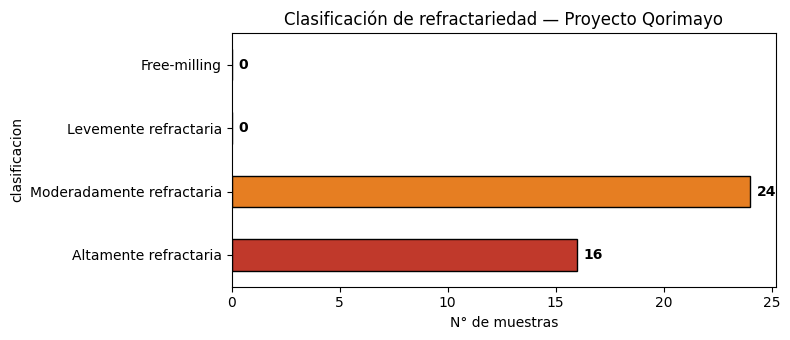

In [2]:
bins = [0, 50, 80, 90, 101]
labels = ["Altamente refractaria", "Moderadamente refractaria",
          "Levemente refractaria", "Free-milling"]
df["clasificacion"] = pd.cut(df["rec_cianuracion_directa_pct"], bins=bins, labels=labels)

conteo = df["clasificacion"].value_counts().reindex(labels)
ax = conteo.plot(kind="barh", color=["#c0392b", "#e67e22", "#f1c40f", "#27ae60"],
                 edgecolor="k", figsize=(8, 3.5))
ax.set_xlabel("N° de muestras"); ax.set_title("Clasificación de refractariedad — Proyecto Qorimayo")
for i, v in enumerate(conteo):
    ax.text(v + 0.3, i, str(v), va="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 2. El encapsulamiento controla la recuperación
Correlacionamos el **% de Au encapsulado en sulfuros** con la recuperación por cianuración directa.

Pendiente: -0.77 % rec. por cada 1% de encapsulamiento
R² = 0.969  |  p-value = 3.56e-30


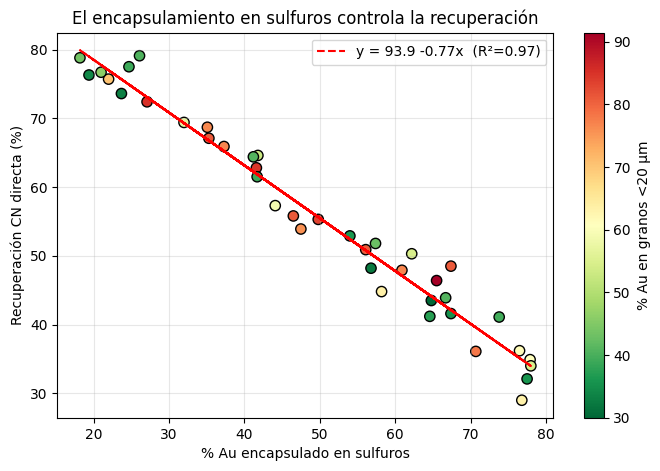

In [3]:
from scipy import stats

x = df["pct_au_encapsulado_sulfuros"]
y = df["rec_cianuracion_directa_pct"]
reg = stats.linregress(x, y)
print(f"Pendiente: {reg.slope:.2f} % rec. por cada 1% de encapsulamiento")
print(f"R² = {reg.rvalue**2:.3f}  |  p-value = {reg.pvalue:.2e}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, c=df["pct_au_granos_menor_20um"], cmap="RdYlGn_r", s=55, edgecolor="k")
plt.plot(x, reg.intercept + reg.slope * x, "r--",
         label=f"y = {reg.intercept:.1f} {reg.slope:+.2f}x  (R²={reg.rvalue**2:.2f})")
plt.colorbar(label="% Au en granos <20 µm")
plt.xlabel("% Au encapsulado en sulfuros"); plt.ylabel("Recuperación CN directa (%)")
plt.title("El encapsulamiento en sulfuros controla la recuperación")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. ¿Cuándo la remolienda deja de servir?
La remolienda libera oro encapsulado en granos "gruesos", pero si el Au está en granos **<20 µm**, la remolienda ya no lo expone. Calculamos la **ganancia por remolienda** y la cruzamos con la finura del oro.

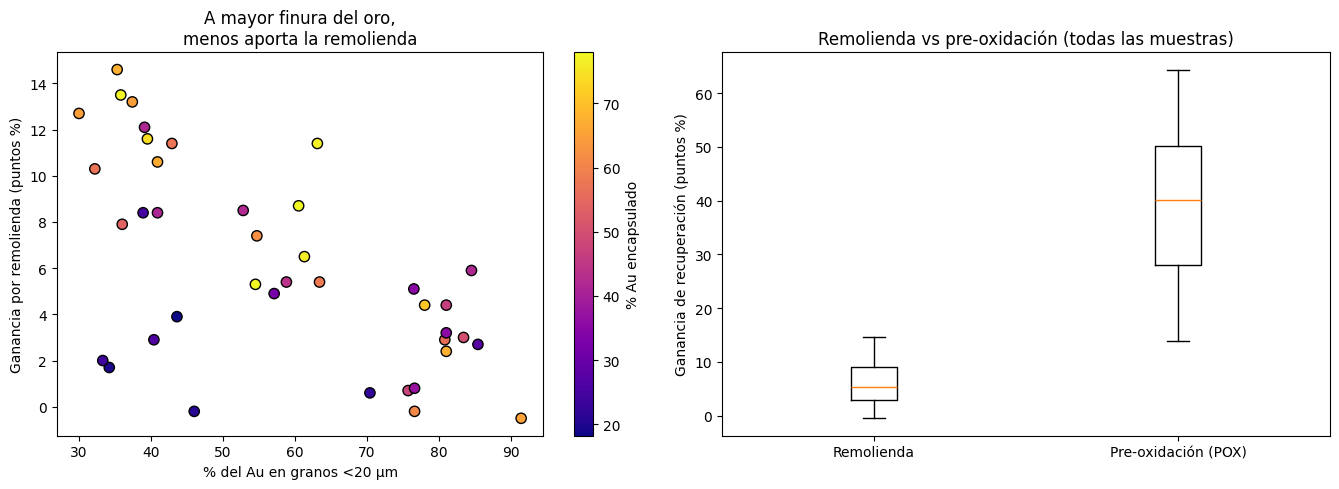

Muestras con Au >70% en granos <20 µm: 14
  Ganancia media remolienda : 2.5 puntos
  Ganancia media POX        : 36.3 puntos


In [4]:
df["ganancia_remolienda"] = df["rec_con_remolienda_pct"] - df["rec_cianuracion_directa_pct"]
df["ganancia_pox"] = df["rec_preoxidacion_pox_pct"] - df["rec_cianuracion_directa_pct"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sc = axes[0].scatter(df["pct_au_granos_menor_20um"], df["ganancia_remolienda"],
                     c=df["pct_au_encapsulado_sulfuros"], cmap="plasma", s=55, edgecolor="k")
axes[0].set_xlabel("% del Au en granos <20 µm")
axes[0].set_ylabel("Ganancia por remolienda (puntos %)")
axes[0].set_title("A mayor finura del oro,\nmenos aporta la remolienda")
plt.colorbar(sc, ax=axes[0], label="% Au encapsulado")

muy_fino = df[df["pct_au_granos_menor_20um"] > 70]
axes[1].boxplot([df["ganancia_remolienda"], df["ganancia_pox"]],
                tick_labels=["Remolienda", "Pre-oxidación (POX)"])
axes[1].set_ylabel("Ganancia de recuperación (puntos %)")
axes[1].set_title("Remolienda vs pre-oxidación (todas las muestras)")
plt.tight_layout(); plt.show()

print(f"Muestras con Au >70% en granos <20 µm: {len(muy_fino)}")
print(f"  Ganancia media remolienda : {muy_fino['ganancia_remolienda'].mean():.1f} puntos")
print(f"  Ganancia media POX        : {muy_fino['ganancia_pox'].mean():.1f} puntos")

> 💡 **Interpretación:** en las muestras donde >70 % del oro está en granos <20 µm, la remolienda aporta muy poco — *"ni con remolienda salen"* — mientras el POX lleva la recuperación a ~95 %+ porque **destruye químicamente** la matriz de sulfuro.

## 4. Evaluación económica simplificada por muestra
¿Cuánto oro adicional (g/t) paga cada ruta? Ingreso extra = ley × Δrecuperación.

In [5]:
PRECIO_AU_USD_G = 108.0   # supuesto: ~3350 US$/oz (simulado)
df["usd_t_extra_remolienda"] = (df["ley_au_g_t"] * df["ganancia_remolienda"] / 100
                                * PRECIO_AU_USD_G).round(2)
df["usd_t_extra_pox"] = (df["ley_au_g_t"] * df["ganancia_pox"] / 100 * PRECIO_AU_USD_G).round(2)

resumen = df.groupby("zona")[["usd_t_extra_remolienda", "usd_t_extra_pox"]].mean().round(2)
print("Ingreso adicional promedio (US$/t) vs cianuración directa:")
resumen

Ingreso adicional promedio (US$/t) vs cianuración directa:


,usd_t_extra_remolienda,usd_t_extra_pox
zona,,
Manto Inti,53.65,322.63
Veta Chaska,31.04,248.49
Veta Killa,54.65,330.35


> El POX genera mucho más valor por tonelada, pero su CAPEX/OPEX es alto: la decisión final requiere un trade-off study completo. Este análisis identifica **qué zonas justifican** el estudio.

## ✅ Conclusiones
1. El % de Au encapsulado en sulfuros explica ~95 % de la variación de la recuperación (R² ≈ 0.95).
2. La remolienda solo ayuda cuando el oro encapsulado NO es ultrafino; con Au <20 µm su aporte es marginal.
3. La pre-oxidación recupera consistentemente >90 % sin importar la refractariedad.

**Siguiente:** [Avanzado 2 — Machine Learning](06_avanzado_ml_recuperacion.ipynb)